![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team: Regina Khamatnurova**
**Dataset:https://cpds-data.org/data/.**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

# Hypothesis Testing and Visualization

This notebook uses SQL queries to investigate the relationship between
government political composition and economic outcomes across 36 countries
between 2000 and 2019.

The analysis focuses on descriptive associations rather than causal effects.

---
## 0. Setup

In [7]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


import sqlite3
from pathlib import Path



---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

´´´
1. GDP growth and government composition
Research question:
How does average real GDP growth differ across government political compositions between 2000 and 2019?
Expectation:
I expect to observe some differences in average GDP growth between government composition categories, although I do not expect political composition alone to explain these differences because economic growth is influenced by many other factors.

2. Unemployment and government composition
Research question:
How does the unemployment rate differ across government political compositions between 2000 and 2019?
Expectation:
I expect unemployment rates to vary across government composition categories. However, I expect substantial variation within each category because unemployment is also influenced by country-specific conditions and broader economic cycles.

3. Inflation 
Research question:
How does inflation differ across government political compositions between 2000 and 2019?
Expectation:
I expect inflation to show differences across government composition categories, but I also expect considerable variation between countries and years.
These work well because you could genuinely be wrong. For example, your SQL analysis might show virtually no meaningful difference in average GDP growth between the categories. That's still a valid result.
´´´

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

The data for this project came from https://cpds-data.org/data/. One row represents different economical factors for 36 countries for each year for the time periog 2000 - 2019

In [8]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.functions import run_query

In [9]:
read_query =  """
    SELECT *
    FROM country_year
    LIMIT 5;
    """
country_year_table = run_query(read_query)

---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

### Research Question 1: GDP Growth

**Question:** How does average real GDP growth differ across government
political compositions between 2000 and 2019?

**Expectation:** Average GDP growth may differ between government composition
categories, but government composition alone is unlikely to explain the
variation in economic growth.

In [10]:
query_gdp = """
SELECT
    gt.government_type,
    ROUND(AVG(cy.gdp_growth), 2) AS avg_gdp_growth,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY gt.government_type_id, gt.government_type
ORDER BY gt.government_type_id;
"""

gdp_by_government = run_query(query_gdp)

#### Finding

Average real GDP growth varies across the five government composition
categories. However, there is no clear linear pattern across the Schmidt
Index categories.

The number of observations also differs substantially between categories,
ranging from 77 to 294 country-year observations. Therefore, these averages
should be interpreted as descriptive associations rather than evidence that
government composition causes differences in GDP growth.

---

### Research Question 2: Unemployment

**Question:** How does average unemployment differ across government
political compositions between 2000 and 2019?

**Expectation:** Unemployment may vary across government composition
categories, while substantial differences may also reflect country-specific
conditions and economic cycles.

In [11]:
query_unemployment = """
SELECT
    gt.government_type,
    ROUND(AVG(cy.unemployment), 2) AS avg_unemployment,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY gt.government_type_id, gt.government_type
ORDER BY gt.government_type_id;
"""

# unemployment_by_government = pd.read_sql(
#     query_unemployment,
#     connection
# )

unemployment_by_government = run_query(query_unemployment)

unemployment_by_government

,government_type,avg_unemployment,observations
0,Hegemony of right-wing and centre parties,7.57,294
1,Dominance of right-wing and centre parties,8.59,129
2,Balance between left and right,7.56,131
3,Dominance of social-democratic and other left ...,9.56,89
4,Hegemony of social-democratic and other left p...,7.46,77


#### Finding

Average unemployment varies across government composition categories, ranging
from 7.46% to 9.56% in the selected period.

As with GDP growth, there is no clear linear pattern across the five Schmidt
Index categories. The number of observations differs substantially between
categories, and the results combine multiple countries and years. Therefore,
the differences should be interpreted as descriptive associations rather than
causal effects of government composition.

---

### Research Question 2: Inflation

In [12]:
query_inflation = """
SELECT
    gt.government_type,
    ROUND(AVG(cy.inflation), 2) AS avg_inflation,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY gt.government_type_id, gt.government_type
ORDER BY gt.government_type_id;
"""

inflation_by_government = run_query(query_inflation)

inflation_by_government

,government_type,avg_inflation,observations
0,Hegemony of right-wing and centre parties,2.18,294
1,Dominance of right-wing and centre parties,2.17,129
2,Balance between left and right,2.64,131
3,Dominance of social-democratic and other left ...,2.44,89
4,Hegemony of social-democratic and other left p...,2.82,77


#### Finding

Average inflation varies moderately across government composition categories,
ranging from 2.17% to 2.82%.

As with GDP growth and unemployment, the averages do not show a clear linear
pattern across the five Schmidt Index categories. These results describe
associations in the pooled country-year data and should not be interpreted
as causal effects of government composition.

---

In [13]:
query_country_gdp = """
SELECT
    c.country_name,
    gt.government_type,
    ROUND(AVG(cy.gdp_growth), 2) AS avg_gdp_growth,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN countries AS c
    ON cy.country_id = c.country_id
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY
    c.country_name,
    gt.government_type_id,
    gt.government_type
HAVING COUNT(*) >= 3
ORDER BY
    c.country_name,
    gt.government_type_id;
"""

# country_gdp = pd.read_sql(
#     query_country_gdp,
#     connection
# )

country_gdp = run_query(query_country_gdp)

country_gdp

,country_name,government_type,avg_gdp_growth,observations
0,Australia,Hegemony of right-wing and centre parties,2.90,13
1,Australia,Hegemony of social-democratic and other left p...,2.71,5
2,Austria,Hegemony of right-wing and centre parties,2.04,8
3,Austria,Balance between left and right,1.22,11
4,Belgium,Hegemony of right-wing and centre parties,1.69,5
...,...,...,...,...
88,Sweden,Hegemony of social-democratic and other left p...,2.72,11
89,Switzerland,Dominance of right-wing and centre parties,1.95,20
90,USA,Hegemony of right-wing and centre parties,2.16,20
91,United Kingdom,Hegemony of right-wing and centre parties,1.94,9


#### Finding

The country-level results show substantial variation in average GDP growth
within the same government composition categories.

This suggests that the overall averages by government type may hide important
country-specific differences. The query includes only country-government type
combinations with at least three observations to avoid comparisons based on
very small groups.

---

In [14]:
query_above_average = """
SELECT
    c.country_name,
    gt.government_type,
    ROUND(AVG(cy.gdp_growth), 2) AS avg_gdp_growth,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN countries AS c
    ON cy.country_id = c.country_id
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY
    c.country_name,
    gt.government_type_id,
    gt.government_type
HAVING
    COUNT(*) >= 3
    AND AVG(cy.gdp_growth) > (
        SELECT AVG(gdp_growth)
        FROM country_year
    )
ORDER BY
    c.country_name,
    gt.government_type_id;
"""

# above_average_gdp = pd.read_sql(
#     query_above_average,
#     connection
# )

above_average_gdp = run_query(query_above_average)

above_average_gdp

,country_name,government_type,avg_gdp_growth,observations
0,Australia,Hegemony of right-wing and centre parties,2.90,13
1,Australia,Hegemony of social-democratic and other left p...,2.71,5
2,Bulgaria,Hegemony of right-wing and centre parties,2.57,6
3,Bulgaria,Dominance of right-wing and centre parties,3.81,9
4,Bulgaria,Balance between left and right,4.00,5
5,Croatia,Balance between left and right,4.39,4
6,Cyprus,Hegemony of right-wing and centre parties,4.43,9
7,Cyprus,Balance between left and right,4.03,7
8,Czech Republic,Balance between left and right,4.53,8
9,Czech Republic,Dominance of social-democratic and other left ...,2.88,3


#### Finding

46 country-government type combinations with at least three observations had
average GDP growth above the overall average for the 2000–2019 dataset.

These combinations occur across different government composition categories
and countries. Together with the previous country-level analysis, this
suggests that country-specific variation is important when interpreting the
overall averages by government composition.

The results remain descriptive and do not establish a causal relationship
between government composition and economic growth.

---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

## Visualization 1: Average GDP Growth by Government Composition

The following chart compares average real GDP growth across the five
government composition categories between 2000 and 2019.

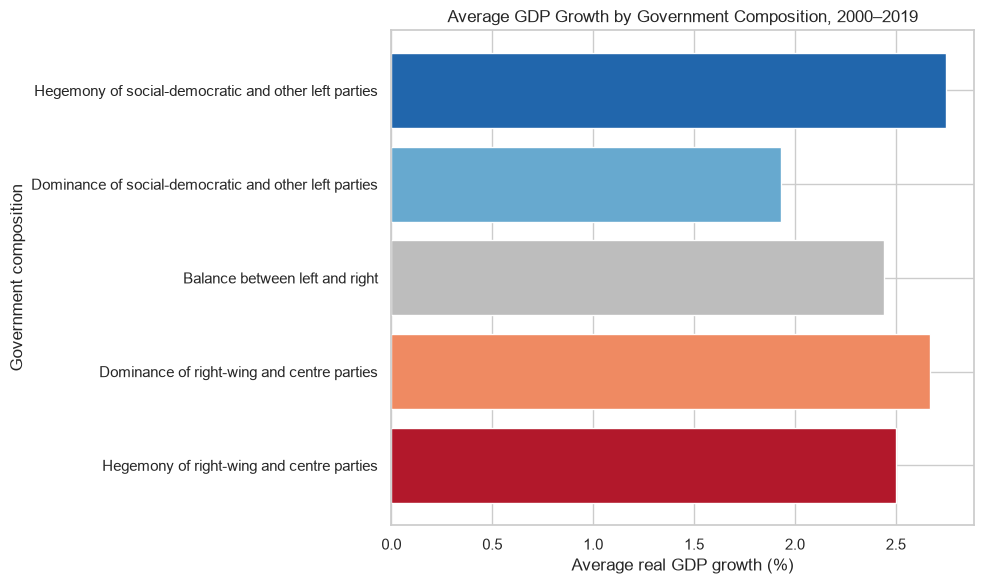

In [15]:
colors = [
    "#B2182B",  # 1 - right/centre hegemony
    "#EF8A62",  # 2 - right/centre dominance
    "#BDBDBD",  # 3 - balance
    "#67A9CF",  # 4 - left dominance
    "#2166AC"   # 5 - left hegemony
]

plt.figure(figsize=(10, 6))

plt.barh(
    gdp_by_government["government_type"],
    gdp_by_government["avg_gdp_growth"],
    color=colors
)

plt.xlabel("Average real GDP growth (%)")
plt.ylabel("Government composition")
plt.title("Average GDP Growth by Government Composition, 2000–2019")

plt.tight_layout()
plt.show()

### Takeaway

Average GDP growth differs across government composition categories, but the
pattern is not linear across the Schmidt Index. The differences are descriptive
associations and do not establish that government composition caused differences
in economic growth.

## Visualization 2: Average Unemployment by Government Composition

The following chart compares average unemployment across the five government
composition categories between 2000 and 2019.

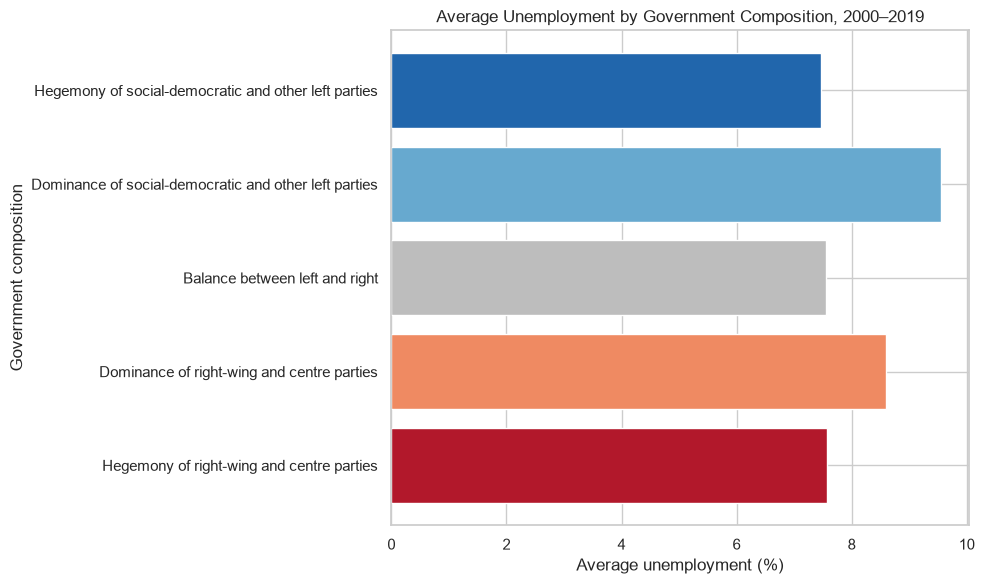

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    unemployment_by_government["government_type"],
    unemployment_by_government["avg_unemployment"],
    color=colors
)

plt.xlabel("Average unemployment (%)")
plt.ylabel("Government composition")
plt.title("Average Unemployment by Government Composition, 2000–2019")

plt.tight_layout()
plt.show()

### Takeaway

Average unemployment varies across government composition categories, but
there is no clear linear pattern across the Schmidt Index. The observed
differences are descriptive and may also reflect country-specific conditions
and economic cycles.

In [17]:
gdp_distribution_query = """
SELECT
    cy.government_type_id,
    gt.government_type,
    cy.gdp_growth
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
ORDER BY cy.government_type_id;
"""

# gdp_distribution = pd.read_sql(
#     gdp_distribution_query,
#     connection
# )

gdp_distribution = run_query(gdp_distribution_query)

gdp_distribution.head()

,government_type_id,government_type,gdp_growth
0,1,Hegemony of right-wing and centre parties,3.386844
1,1,Hegemony of right-wing and centre parties,2.714849
2,1,Hegemony of right-wing and centre parties,4.010583
3,1,Hegemony of right-wing and centre parties,3.119654
4,1,Hegemony of right-wing and centre parties,3.964010


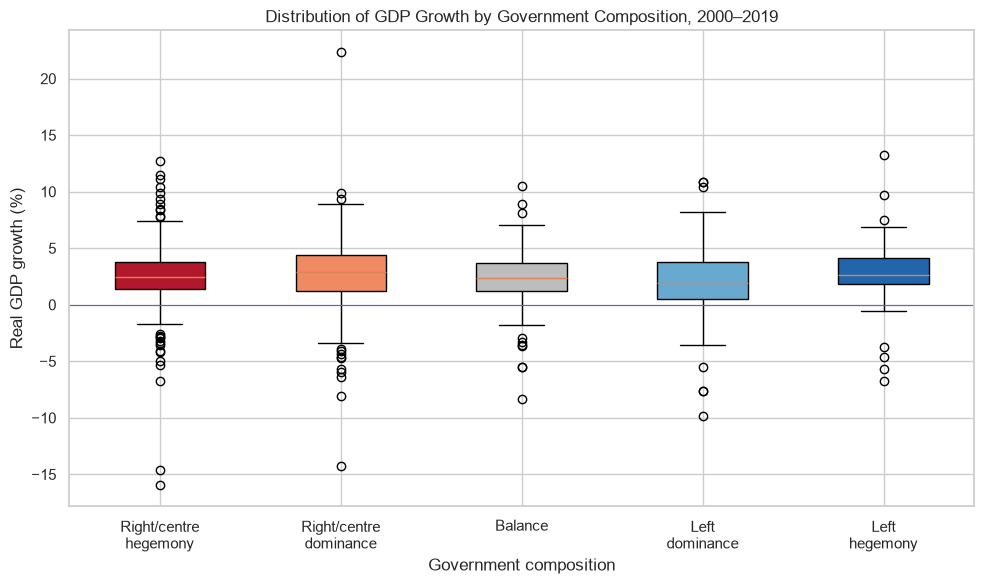

In [18]:
plt.figure(figsize=(10, 6))

data_to_plot = [
    gdp_distribution[
        gdp_distribution["government_type_id"] == i
    ]["gdp_growth"]
    for i in range(1, 6)
]

boxplot = plt.boxplot(
    data_to_plot,
    patch_artist=True
)

for box, color in zip(boxplot["boxes"], colors):
    box.set_facecolor(color)

plt.xticks(
    range(1, 6),
    [
        "Right/centre\nhegemony",
        "Right/centre\ndominance",
        "Balance",
        "Left\ndominance",
        "Left\nhegemony"
    ]
)

plt.xlabel("Government composition")
plt.ylabel("Real GDP growth (%)")
plt.title("Distribution of GDP Growth by Government Composition, 2000–2019")

plt.axhline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Takeaway

GDP growth distributions are broadly similar across the five government
composition categories, with substantial overlap between them.

The right-wing and centre government categories show more negative outliers
than the left-wing categories in this dataset. However, these outliers
represent individual country-year observations and should not be interpreted
as evidence that government composition caused the negative GDP growth.

In [19]:
query_party_over_time = """
SELECT
    cy.year,
    cy.government_type_id,
    gt.government_type,
    COUNT(*) AS countries
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY
    cy.year,
    cy.government_type_id,
    gt.government_type
ORDER BY
    cy.year,
    cy.government_type_id;
"""

# party_over_time = pd.read_sql(query_party_over_time, connection)

party_over_time = run_query(query_party_over_time)

party_over_time.head(10)

,year,government_type_id,government_type,countries
0,2000,1,Hegemony of right-wing and centre parties,13
1,2000,2,Dominance of right-wing and centre parties,6
2,2000,3,Balance between left and right,6
3,2000,4,Dominance of social-democratic and other left ...,5
4,2000,5,Hegemony of social-democratic and other left p...,6
5,2001,1,Hegemony of right-wing and centre parties,11
6,2001,2,Dominance of right-wing and centre parties,9
7,2001,3,Balance between left and right,5
8,2001,4,Dominance of social-democratic and other left ...,4
9,2001,5,Hegemony of social-democratic and other left p...,7


In [20]:
party_pivot = party_over_time.pivot(
    index="year",
    columns="government_type_id",
    values="countries"
).fillna(0)

party_pivot.head()

government_type_id,1,2,3,4,5
year,,,,,
2000,13,6,6,5,6
2001,11,9,5,4,7
2002,14,7,7,2,6
2003,19,2,7,2,6
2004,18,5,5,4,4


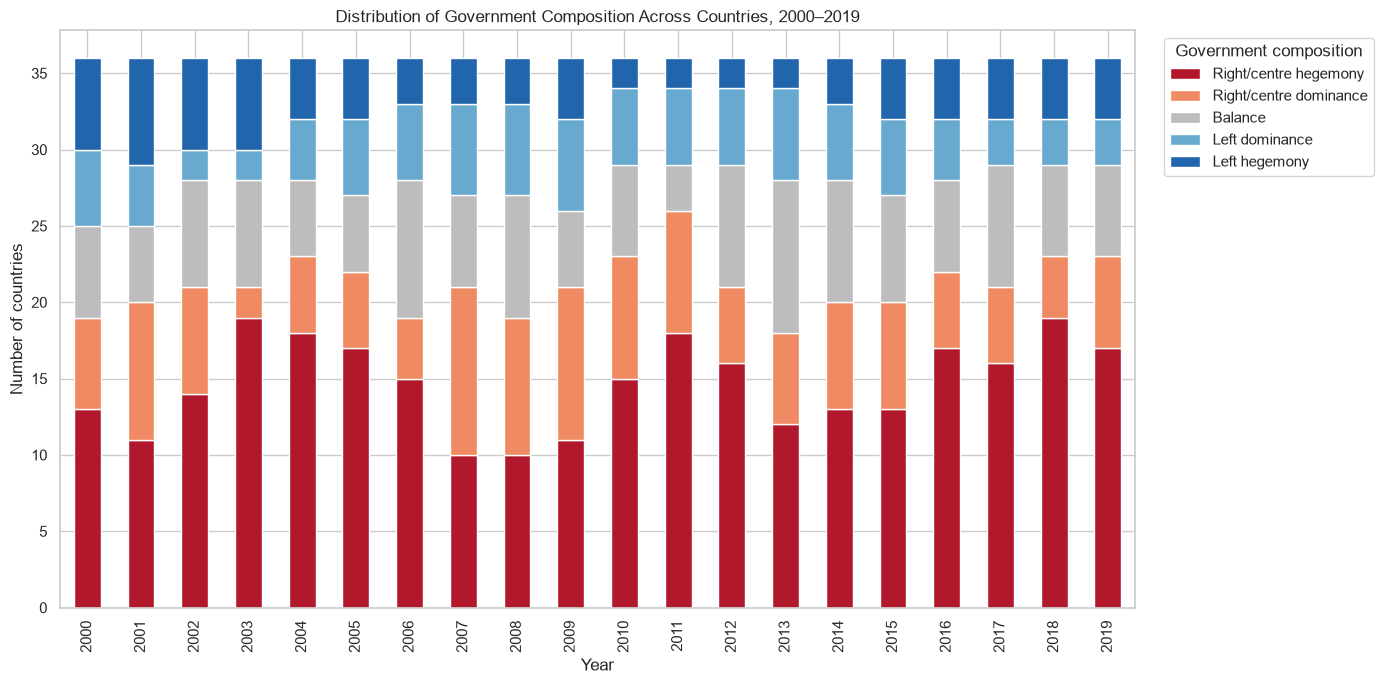

In [21]:
party_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=colors
)

plt.xlabel("Year")
plt.ylabel("Number of countries")
plt.title("Distribution of Government Composition Across Countries, 2000–2019")

plt.legend(
    [
        "Right/centre hegemony",
        "Right/centre dominance",
        "Balance",
        "Left dominance",
        "Left hegemony"
    ],
    title="Government composition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [22]:
query_gdp_over_time = """
SELECT
    cy.year,
    cy.government_type_id,
    gt.government_type,
    AVG(cy.gdp_growth) AS avg_gdp_growth,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY
    cy.year,
    cy.government_type_id,
    gt.government_type
ORDER BY
    cy.year,
    cy.government_type_id;
"""

# gdp_over_time = pd.read_sql(query_gdp_over_time, connection)

gdp_over_time = run_query(query_gdp_over_time)

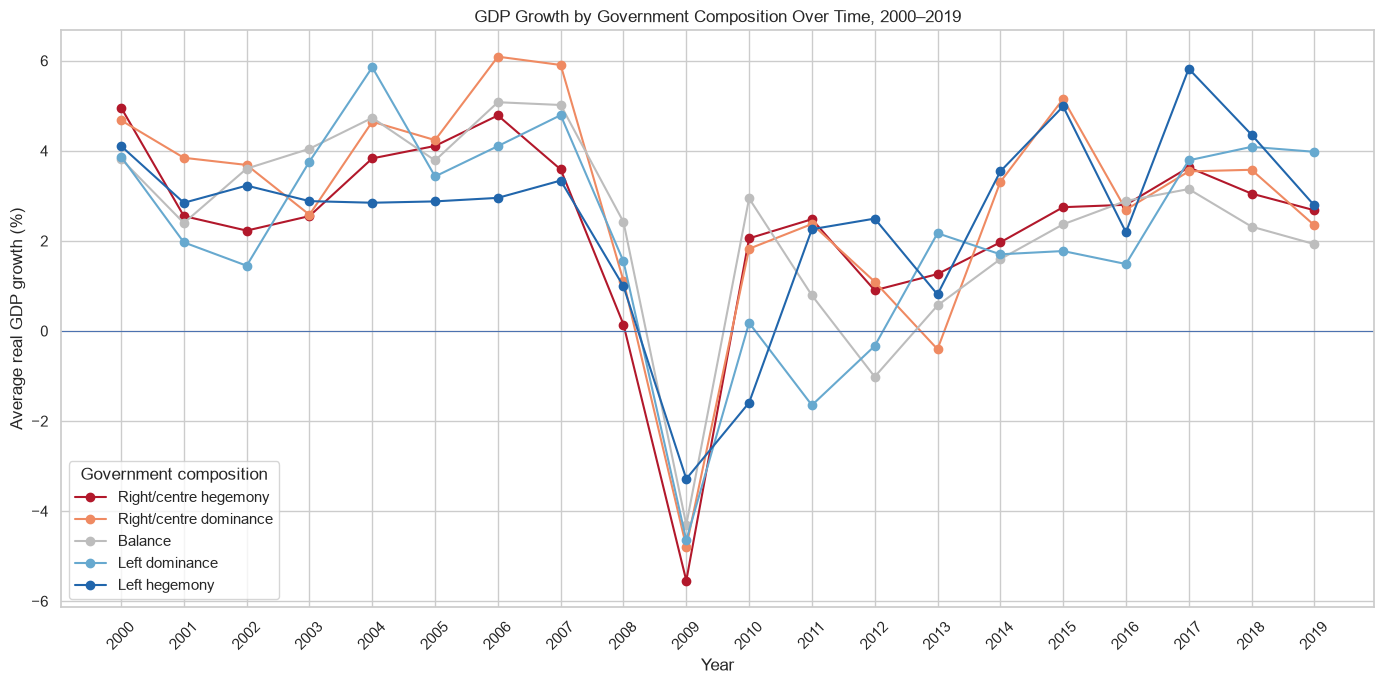

In [23]:
plt.figure(figsize=(14, 7))

for government_type_id, color in zip(range(1, 6), colors):

    subset = gdp_over_time[
        gdp_over_time["government_type_id"] == government_type_id
    ]

    plt.plot(
        subset["year"],
        subset["avg_gdp_growth"],
        marker="o",
        color=color,
        label=government_type_id
    )

plt.axhline(0, linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Average real GDP growth (%)")
plt.title("GDP Growth by Government Composition Over Time, 2000–2019")

plt.legend(
    [
        "Right/centre hegemony",
        "Right/centre dominance",
        "Balance",
        "Left dominance",
        "Left hegemony"
    ],
    title="Government composition"
)

plt.xticks(range(2000, 2020), rotation=45)

plt.tight_layout()
plt.show()

### Takeaway

Average GDP growth changes substantially over time across all government
composition categories. The categories frequently move in similar directions,
including a pronounced decline around 2009 followed by a recovery.

The lines also cross repeatedly, and no government composition category
consistently shows higher or lower average GDP growth throughout the
2000–2019 period.

This suggests that year-specific and broader economic conditions are important
when interpreting the relationship between government composition and GDP
growth. The observed differences between categories are descriptive and do
not establish causal effects.

---

In [24]:
query_unemployment_over_time = """
SELECT
    cy.year,
    cy.government_type_id,
    gt.government_type,
    AVG(cy.unemployment) AS avg_unemployment,
    COUNT(*) AS observations
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
GROUP BY
    cy.year,
    cy.government_type_id,
    gt.government_type
ORDER BY
    cy.year,
    cy.government_type_id;
"""

# unemployment_over_time = pd.read_sql(
#     query_unemployment_over_time,
#     connection
# )

unemployment_over_time = run_query(query_unemployment_over_time)

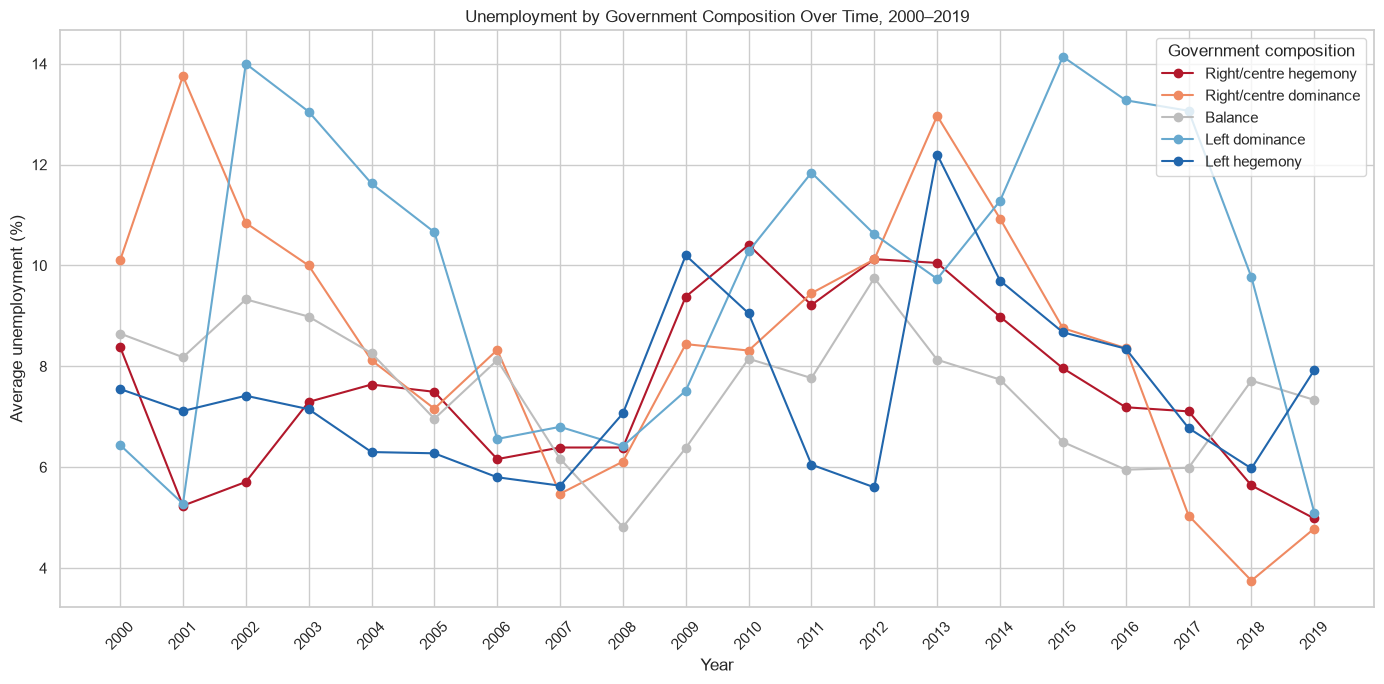

In [25]:
plt.figure(figsize=(14, 7))

for government_type_id, color in zip(range(1, 6), colors):

    subset = unemployment_over_time[
        unemployment_over_time["government_type_id"] == government_type_id
    ]

    plt.plot(
        subset["year"],
        subset["avg_unemployment"],
        marker="o",
        color=color,
        label=government_type_id
    )

plt.xlabel("Year")
plt.ylabel("Average unemployment (%)")
plt.title(
    "Unemployment by Government Composition Over Time, 2000–2019"
)

plt.legend(
    [
        "Right/centre hegemony",
        "Right/centre dominance",
        "Balance",
        "Left dominance",
        "Left hegemony"
    ],
    title="Government composition"
)

plt.xticks(range(2000, 2020), rotation=45)

plt.tight_layout()
plt.show()

### Takeaway

Average unemployment varies substantially over time within all five government
composition categories, and the lines cross frequently throughout the
2000–2019 period.

Unlike the GDP growth trends, unemployment does not show an equally strong
common pattern across all five categories. Some categories also show large
year-to-year changes, consistent with the differences in unemployment
variability observed in the standard-deviation analysis.

No government composition category remains consistently associated with
higher or lower unemployment throughout the full period.

Because the countries represented within each category can change from year
to year, these patterns reflect both changes in unemployment and changes in
the composition of the groups. They should therefore be interpreted as
descriptive associations rather than causal effects.

---

In [26]:
stability_query = """
SELECT
    cy.government_type_id,
    gt.government_type,
    cy.gdp_growth
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
ORDER BY cy.government_type_id;
"""

# stability_data = pd.read_sql(stability_query, connection)

stability_data = run_query(stability_query)

In [27]:
gdp_stability = (
    stability_data
    .groupby(["government_type_id", "government_type"])["gdp_growth"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

gdp_stability

,government_type_id,government_type,mean,std,count
0,1,Hegemony of right-wing and centre parties,2.498878,2.999480,294
1,2,Dominance of right-wing and centre parties,2.673065,3.995465,129
2,3,Balance between left and right,2.439118,2.726201,131
3,4,Dominance of social-democratic and other left ...,1.929768,3.476950,89
4,5,Hegemony of social-democratic and other left p...,2.752648,2.821045,77


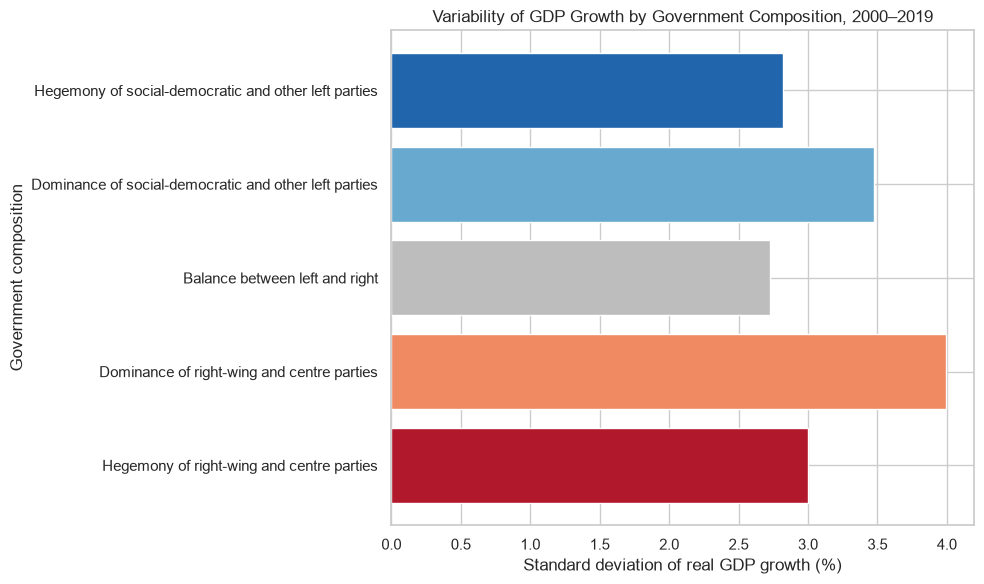

In [28]:
plt.figure(figsize=(10, 6))

plt.barh(
    gdp_stability["government_type"],
    gdp_stability["std"],
    color=colors
)

plt.xlabel("Standard deviation of real GDP growth (%)")
plt.ylabel("Government composition")
plt.title("Variability of GDP Growth by Government Composition, 2000–2019")

plt.tight_layout()
plt.show()

In [29]:
unemployment_stability_query = """
SELECT
    cy.government_type_id,
    gt.government_type,
    cy.unemployment
FROM country_year AS cy
INNER JOIN government_types AS gt
    ON cy.government_type_id = gt.government_type_id
ORDER BY cy.government_type_id;
"""

# unemployment_stability_data = pd.read_sql(
#     unemployment_stability_query,
#     connection
# )

unemployment_stability_data = run_query(unemployment_stability_query)

In [30]:
unemployment_stability = (
    unemployment_stability_data
    .groupby(["government_type_id", "government_type"])["unemployment"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

unemployment_stability

,government_type_id,government_type,mean,std,count
0,1,Hegemony of right-wing and centre parties,7.571429,4.076839,294
1,2,Dominance of right-wing and centre parties,8.593798,5.028011,129
2,3,Balance between left and right,7.560305,3.416671,131
3,4,Dominance of social-democratic and other left ...,9.556180,5.387822,89
4,5,Hegemony of social-democratic and other left p...,7.464935,2.941659,77


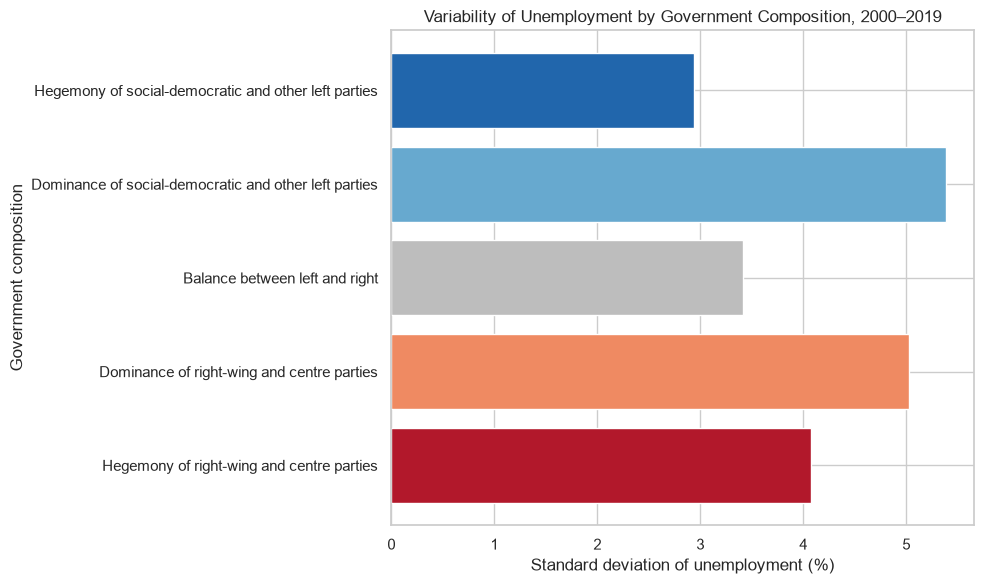

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    unemployment_stability["government_type"],
    unemployment_stability["std"],
    color=colors
)

plt.xlabel("Standard deviation of unemployment (%)")
plt.ylabel("Government composition")
plt.title("Variability of Unemployment by Government Composition, 2000–2019")

plt.tight_layout()
plt.show()

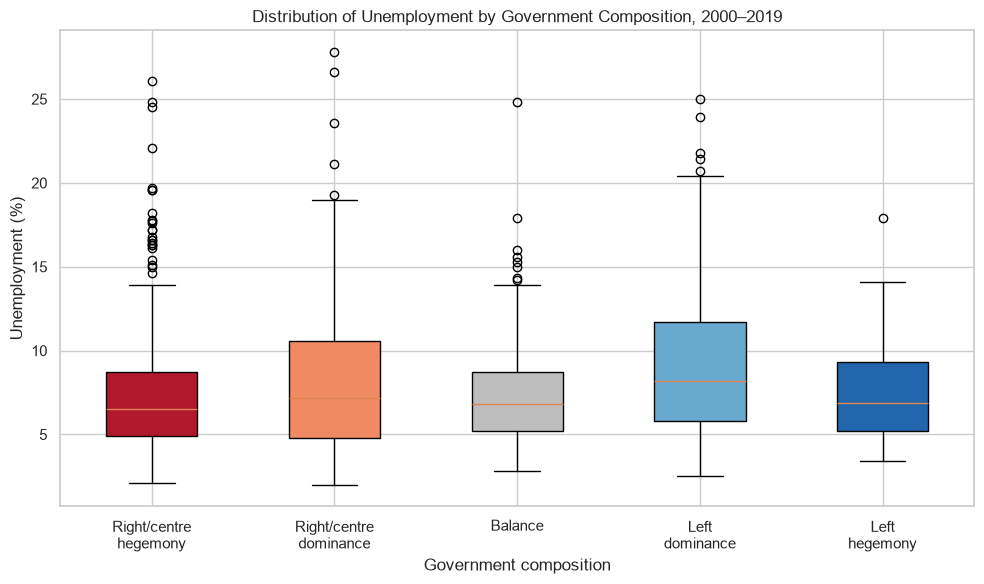

In [32]:
plt.figure(figsize=(10, 6))

data_to_plot = [
    unemployment_stability_data[
        unemployment_stability_data["government_type_id"] == i
    ]["unemployment"]
    for i in range(1, 6)
]

boxplot = plt.boxplot(
    data_to_plot,
    patch_artist=True
)

for box, color in zip(boxplot["boxes"], colors):
    box.set_facecolor(color)

plt.xticks(
    range(1, 6),
    [
        "Right/centre\nhegemony",
        "Right/centre\ndominance",
        "Balance",
        "Left\ndominance",
        "Left\nhegemony"
    ]
)

plt.xlabel("Government composition")
plt.ylabel("Unemployment (%)")
plt.title("Distribution of Unemployment by Government Composition, 2000–2019")

plt.tight_layout()
plt.show()

### Takeaway

Unemployment distributions overlap substantially across all five government
composition categories, although their variability differs.

The dominance categories (2 and 4) show wider distributions, while category 5
has a comparatively narrower distribution in this dataset. Category 1 also
contains numerous high-unemployment outliers despite a relatively compact
central distribution.

Overall, government composition does not clearly separate countries into
distinct unemployment distributions. The observed differences may also reflect
country-specific conditions and economic cycles and should not be interpreted
as causal effects of government composition.

---
## 5. Conclusions

Answer each question. Say whether your hypothesis held. Being wrong is a fine result, as long as you say so and show the evidence.

Initial expectation: Government political composition would be associated with differences in economic stability.
Observed result: The descriptive analysis did not reveal a consistent relationship between the Schmidt Index categories and economic stability. GDP growth often followed similar time patterns across categories, while unemployment showed substantial variation across countries, years, and government compositions.
Interpretation: Government composition alone does not appear sufficient to explain the economic patterns observed in this analysis. The results suggest that country-specific and time-specific factors are important and that further analysis would be needed to isolate their effects.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.